# Target Brazil: Operations & Customer Growth Analysis

---




# 1. Executive Summary
This project analyzes the operational performance and growth trajectory of Target in the Brazilian market. By evaluating approximately 100,000 orders spanning a 25-month period, this study identifies a core paradox: while customer satisfaction is high due to frequent early deliveries, a conservative logistics algorithm may be inadvertently stifling conversion rates. This analysis offers a strategic roadmap for geographic expansion into the North/Northeast regions and suggests an inventory pivot toward high-end goods to leverage Brazil’s installment-based payment culture.

# 2. Objective
The objective of this analysis is to transition Target Brazil from a regional player to a national leader by solving logistical bottlenecks.

# 3. Data Infrastructure

## 3.1 Data Infrastructure
Google BigQuery is used for large-scale data processing and Python for visualization.

Data are integrated data from eight primary operational tables: customers, geolocation, orders, order_items, order_reviews, payments, products, and sellers, for a full overview.



In [9]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Authentication and Client Setup
auth.authenticate_user()
client = bigquery.Client(project='scaler-dsml-sql-485615')

def run_query(query):
    return client.query(query).to_dataframe()

Data are integrated data from eight primary operational tables: customers, geolocation, orders, order_items, order_reviews, payments, products, and sellers.

# 4. Market Growth and Performance Trends

## 4.1 Operational Timeline

In [10]:
query = """

SELECT MIN(order_purchase_timestamp) AS start_date,
       MAX(order_purchase_timestamp) AS end_date
FROM `Target.orders`;
"""

run_query(query)

,start_date,end_date
0,2016-09-04 21:15:19+00:00,2018-10-17 17:30:18+00:00


The data reveals a 25-month operational window, starting from September 4, 2016 until October 17, 2018.

## 4.2 Order Trends and Growth Dynamics

Is Target Brazil growing? To study that, we can visualize the monthly order volume to distinguish between organic growth and seasonal spikes.

In [11]:
query = """

SELECT FORMAT_DATE('%Y-%m', order_purchase_timestamp) AS year_month,
       COUNT(order_id) AS order_count
FROM `Target.orders`
GROUP BY 1
ORDER BY 1


"""
df = run_query(query)

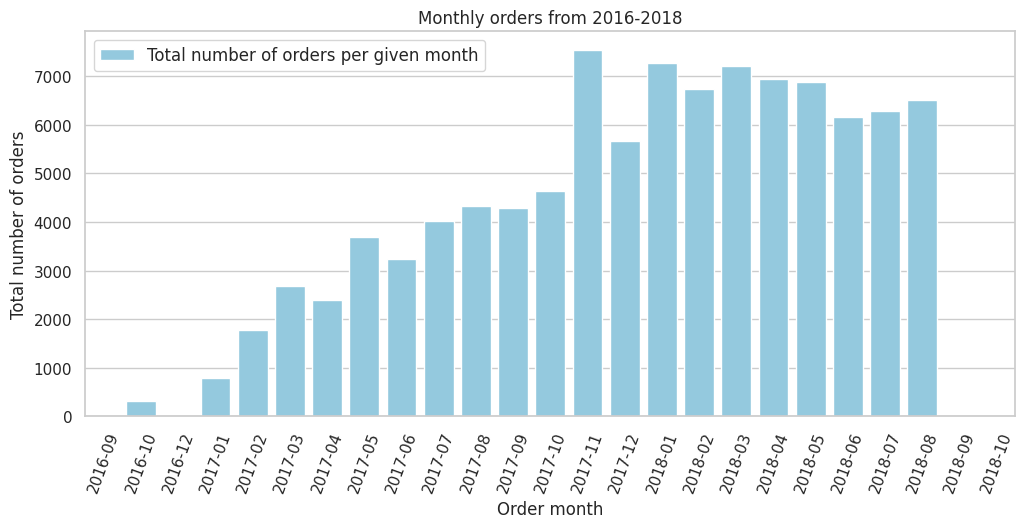

In [12]:
# @title
plt.rcParams["figure.figsize"] = (12, 5)

sns.set(style="whitegrid")

sns.barplot(data=df, x='year_month', y='order_count', color='skyblue', label='Total number of orders per given month')

plt.title('Monthly orders from 2016-2018', fontsize=12)
plt.xlabel('Order month', fontsize=12)
plt.ylabel('Total number of orders', fontsize=12)

plt.xticks(rotation=70)

plt.legend(loc='upper left', fontsize=12)
plt.savefig('monthly_order_trend.png', bbox_inches='tight')
plt.show()
plt.close()

The data collection is characterized by significant anomalies at both ends of the timeline. In late 2016, recording appears inconsistent with irregular jumps and missing data in November, while the end of 2018 shows an abrupt collapse in recorded volume, dropping from over 6,000 orders to just 16 and 4 in the final two months. However, when these anomalous tails are excluded to focus on the stable window between January 2017 and August 2018, a clear narrative of sustained expansion emerges. During this period, the business scaled rapidly from 800 monthly orders to a consistent volume exceeding 7,000 orders by early 2018, demonstrating a smooth and successful trajectory of customer base growth.


**Seasonality:**

To study seasonality effectively and optimize logistical strategies, it is essential to use metrics that account for data inconsistencies. In this dataset, relying on the absolute sum or simple monthly averages would produce skewed results because several months (such as November and September) contain incomplete or missing data across different years. To circumvent this bias and prevent underestimating demand, the average daily order metric is used. This approach normalizes the data by calculating the average number of orders placed per day within a given month, ensuring a reliable representation of seasonal trends regardless of missing dates.



In [13]:
query = """

WITH daily_average AS (
       SELECT DATE(order_purchase_timestamp) AS order_date,
              EXTRACT(MONTH FROM order_purchase_timestamp) AS month_num,
              FORMAT_DATE('%B', order_purchase_timestamp) AS month_name,
              COUNT(order_id) AS total_orders
    FROM `Target.orders`
    GROUP BY 1, 2, 3
)
SELECT month_name,
       ROUND(AVG(total_orders), 2) AS daily_avg_orders
FROM daily_average
GROUP BY month_num, month_name
ORDER BY month_num;

"""

df = run_query(query)

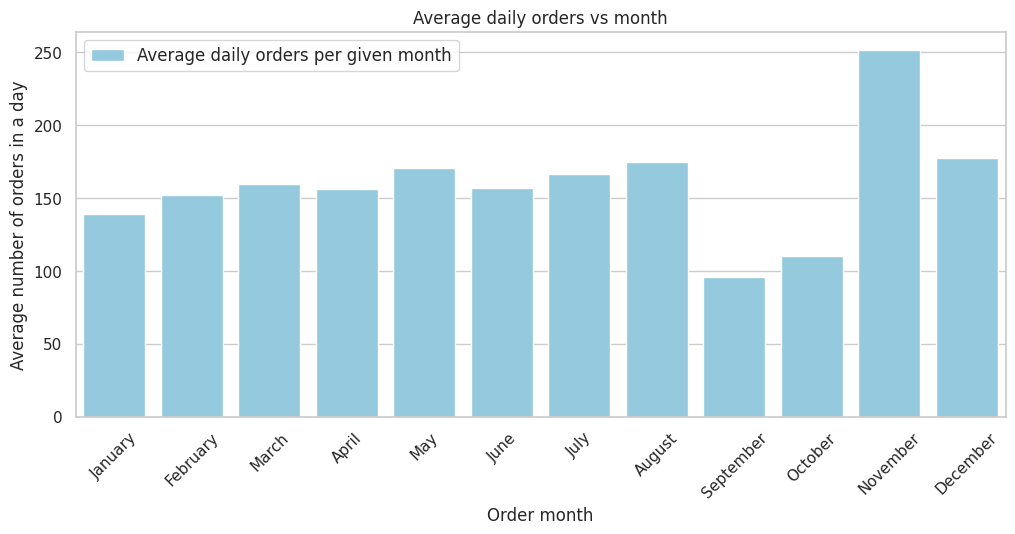

In [14]:
# @title
sns.set(style="whitegrid")

sns.barplot(data=df, x='month_name', y='daily_avg_orders', color='skyblue', label='Average daily orders per given month')

plt.title('Average daily orders vs month', fontsize=12)
plt.xlabel('Order month', fontsize=12)
plt.ylabel('Average number of orders in a day', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper left', fontsize=12)
plt.savefig('avg_daily_orders.png', bbox_inches='tight')
plt.show()
plt.close()

**Key Findings:**

The analysis identifies November as the peak period for order volume, recording the highest average daily orders, followed by December, August, and May. These trends align with major cultural and commercial milestones in Brazil: the November surge is primarily attributed to Black Friday promotions, while the high volume in December reflects Christmas gift-shopping. Additionally, the spikes in May and August correspond with Mother's Day and Father's Day, respectively—both significant retail events in the Brazilian market.

Ultimately, these findings indicate that Target's sales performance in Brazil is heavily influenced by seasonal celebrations and promotional events.


Beyond these broad monthly trends, consumer behavior also exhibits distinct patterns on a more granular, hourly scale. While seasonal events dictate which months see the most volume, local daily habits and work-life structures influence the specific times of day when customers are most active. This leads to a noticeable concentration of purchasing activity during specific daylight hours.

In [15]:
query = """

SELECT CASE WHEN EXTRACT(HOUR FROM order_purchase_timestamp) BETWEEN 0 AND 6 THEN 'Dawn' -- 00:00:00 to 06:59:59
            WHEN EXTRACT(HOUR FROM order_purchase_timestamp) BETWEEN 7 AND 12 THEN 'Morning' -- 07:00:00 to 12:59:59
            WHEN EXTRACT(HOUR FROM order_purchase_timestamp) BETWEEN 13 AND 18 THEN 'Afternoon' -- 13:00:00 to 18:59:59
            WHEN EXTRACT(HOUR FROM order_purchase_timestamp) BETWEEN 19 AND 23 THEN 'Night' -- 19:00:00 to 23:59:59
       END AS time_of_day,
       COUNT(order_id) AS total_orders
FROM `Target.orders`
GROUP BY 1
ORDER BY 2 DESC;

"""

df = run_query(query)
df

,time_of_day,total_orders
0,Afternoon,38135
1,Night,28331
2,Morning,27733
3,Dawn,5242


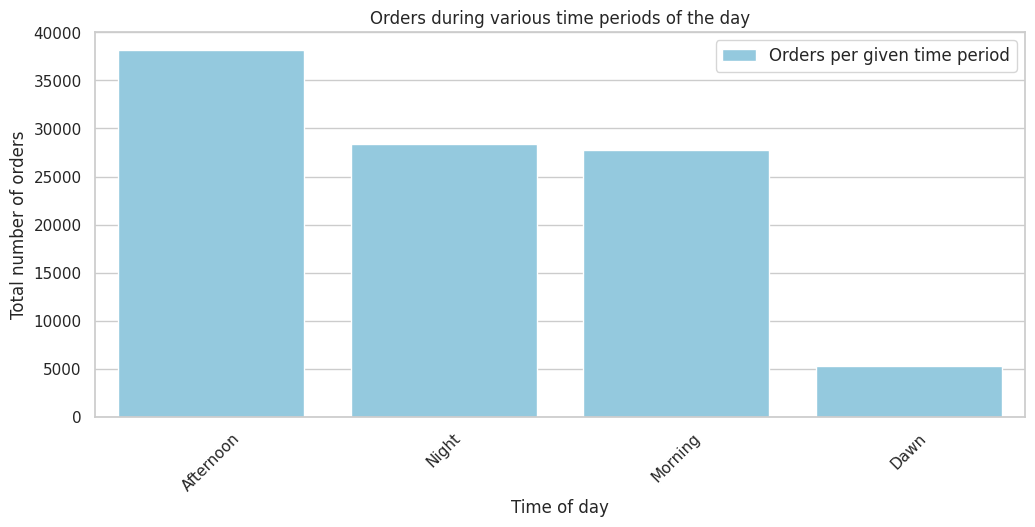

In [16]:
# @title
sns.set(style="whitegrid")

sns.barplot(data=df, x='time_of_day', y='total_orders', color='skyblue', label='Orders per given time period')

plt.title('Orders during various time periods of the day', fontsize=12)
plt.xlabel('Time of day', fontsize=12)
plt.ylabel('Total number of orders', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.savefig('orders_timeperiod.png', bbox_inches='tight')
plt.show()
plt.close()

Order distribution by time of day reveals that the majority of transactions occur during the afternoon. This peak in activity likely correlates with daily routines, such as online shopping during lunch breaks at work or during after-work commutes, suggesting that convenience and daily downtime are the primary drivers of purchase timing.

While the order volume and peak time periods tell us when the customers shop, the financial evolution of these orders reveals the true scale of Target's market penetration. By shifting our focus from order counts to total payment values, we can evaluate the company's transition from an emerging player in 2017 to a stabilized market force by mid-2018.

# 5. Financial Growth & Revenue Stability Analysis

**Revenue Momentum and the 2018 Plateau:**

Due to the incomplete data at the tails, let us consider only the months from January to August in 2017 and 2018.

A sequential analysis of monthly payment values shows that Target experienced a period of aggressive scaling throughout 2017. While the data shows a sharp 65% "jump" in January 2018, it is important to contextualize this as a result of sustained momentum from the previous year's end rather than an isolated monthly spike. By 2018, the revenue trend reached a significant milestone, stabilizing at a consistent "plateau" of over R$ 1 million per month. This indicates that after a phase of rapid acquisition, the business has moved into a mature phase of steady, predictable revenue.

In [17]:
query = """

WITH monthly_totalpayments AS (
       SELECT FORMAT_DATE('%Y-%m', o.order_purchase_timestamp) AS order_month,
              SUM(p.payment_value) AS total_order_cost
       FROM `Target.orders` o
       INNER JOIN `Target.payments` p
       ON o.order_id = p.order_id
       WHERE EXTRACT(MONTH FROM o.order_purchase_timestamp) BETWEEN 1 AND 8 AND EXTRACT(YEAR FROM o.order_purchase_timestamp) IN (2017,2018)
       GROUP BY 1
)

SELECT order_month,
       ROUND(total_order_cost,2) AS order_cost,
       ROUND(LAG(total_order_cost) OVER (ORDER BY order_month),2) AS prev_month_cost,
       ROUND(total_order_cost-LAG(total_order_cost) OVER (ORDER BY order_month),2) AS increase,
       ROUND(100*(total_order_cost-LAG(total_order_cost) OVER (ORDER BY order_month))/LAG(total_order_cost) OVER (ORDER BY order_month),2) AS percentage_increase
FROM monthly_totalpayments;

"""

df = run_query(query)

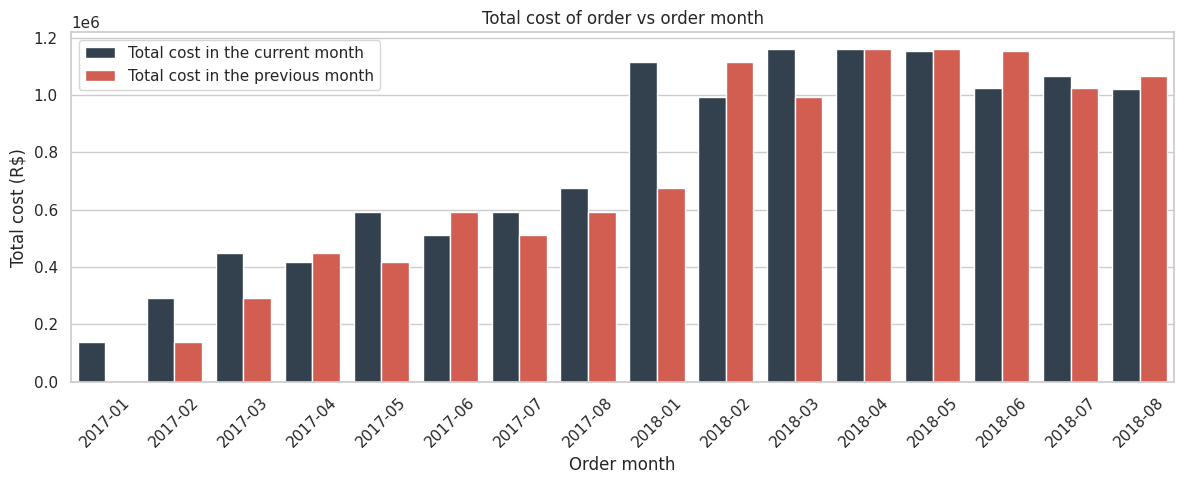

In [18]:
# @title
df_melted = df.melt(id_vars='order_month', value_vars=['order_cost', 'prev_month_cost'])

sns.barplot(data=df_melted, x='order_month', y='value', hue='variable', palette=['#2E4053', '#E74C3C'])

plt.title('Total cost of order vs order month', fontsize=12)
plt.xlabel('Order month', fontsize=12)
plt.ylabel('Total cost (R$)', fontsize=12)
plt.xticks(rotation=45)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Total cost in the current month', 'Total cost in the previous month'], title=None)


plt.tight_layout()
plt.savefig('order_cost_month_comparison.png')


**Year-over-Year Comparative Performance:**

Comparing the first eight months of 2017 against the same period in 2018 highlights the explosive nature of Target's early growth in Brazil.

In January 2017, monthly revenue stood at approximately R$ 139k. By January 2018, this figure surged to over R$ 1.1 million—a staggering 705% year-over-year increase.

As 2018 progressed, the year-over-year growth gap naturally narrowed from 705% to 50% by August. Rather than a slowdown, this contraction reflects the company's evolution from a low-baseline startup phase in 2017 to a robust, high-volume operation in 2018.

In [19]:
query = """

WITH monthly_payments AS (
       SELECT
              EXTRACT(MONTH FROM o.order_purchase_timestamp) AS month_num,
              SUM(CASE WHEN EXTRACT(YEAR FROM o.order_purchase_timestamp) = 2017 THEN p.payment_value ELSE 0 END) AS cost_2017,
              SUM(CASE WHEN EXTRACT(YEAR FROM o.order_purchase_timestamp) = 2018 THEN p.payment_value ELSE 0 END) AS cost_2018
       FROM `Target.orders` o
       INNER JOIN `Target.payments` p ON o.order_id = p.order_id
       WHERE EXTRACT(MONTH FROM o.order_purchase_timestamp) BETWEEN 1 AND 8
       GROUP BY 1
)
SELECT month_num,
       ROUND(cost_2017,2) AS cost_2017,
       ROUND(cost_2018,2) AS cost_2018,
       ROUND(100*(cost_2018-cost_2017)/cost_2017,2) AS yearly_growth_percentage
FROM monthly_payments
ORDER BY 4 DESC;

"""

run_query(query)

,month_num,cost_2017,cost_2018,yearly_growth_percentage
0,1,138488.04,1115004.18,705.13
1,2,291908.01,992463.34,239.99
2,4,417788.03,1160785.48,177.84
3,3,449863.60,1159652.12,157.78
4,6,511276.38,1023880.50,100.26
5,5,592918.82,1153982.15,94.63
6,7,592382.92,1066540.75,80.04
7,8,674396.32,1022425.32,51.61


**Key Findings:**

In summary, the financial data confirms that Target successfully navigated its entry into the Brazilian market, transforming from a nascent e-commerce platform into a stable million-real-per-month enterprise within less than two years.

# 6. Geography & Logistics Challenge

To ensure the business analysis is geographically grounded, it is essential to first examine the administrative landscape of Brazil. The country's 27 states are organized into five distinct regions - North, Center-West, North East, South East and South, each defined by unique economic and environmental characteristics.

Geography plays a critical role in logistical complexity; nearly 60% of Brazil's territory is occupied by the Amazon rainforest. This vast biotype encompasses nine states, covering the entirety of the North region (AC, AM, RO, RR, PA, AP, TO) and extending into portions of the Center-West (MT) and Northeast (MA). Understanding this geographic distribution is vital, as it directly impacts delivery timelines and infrastructure requirements for e-commerce operations.

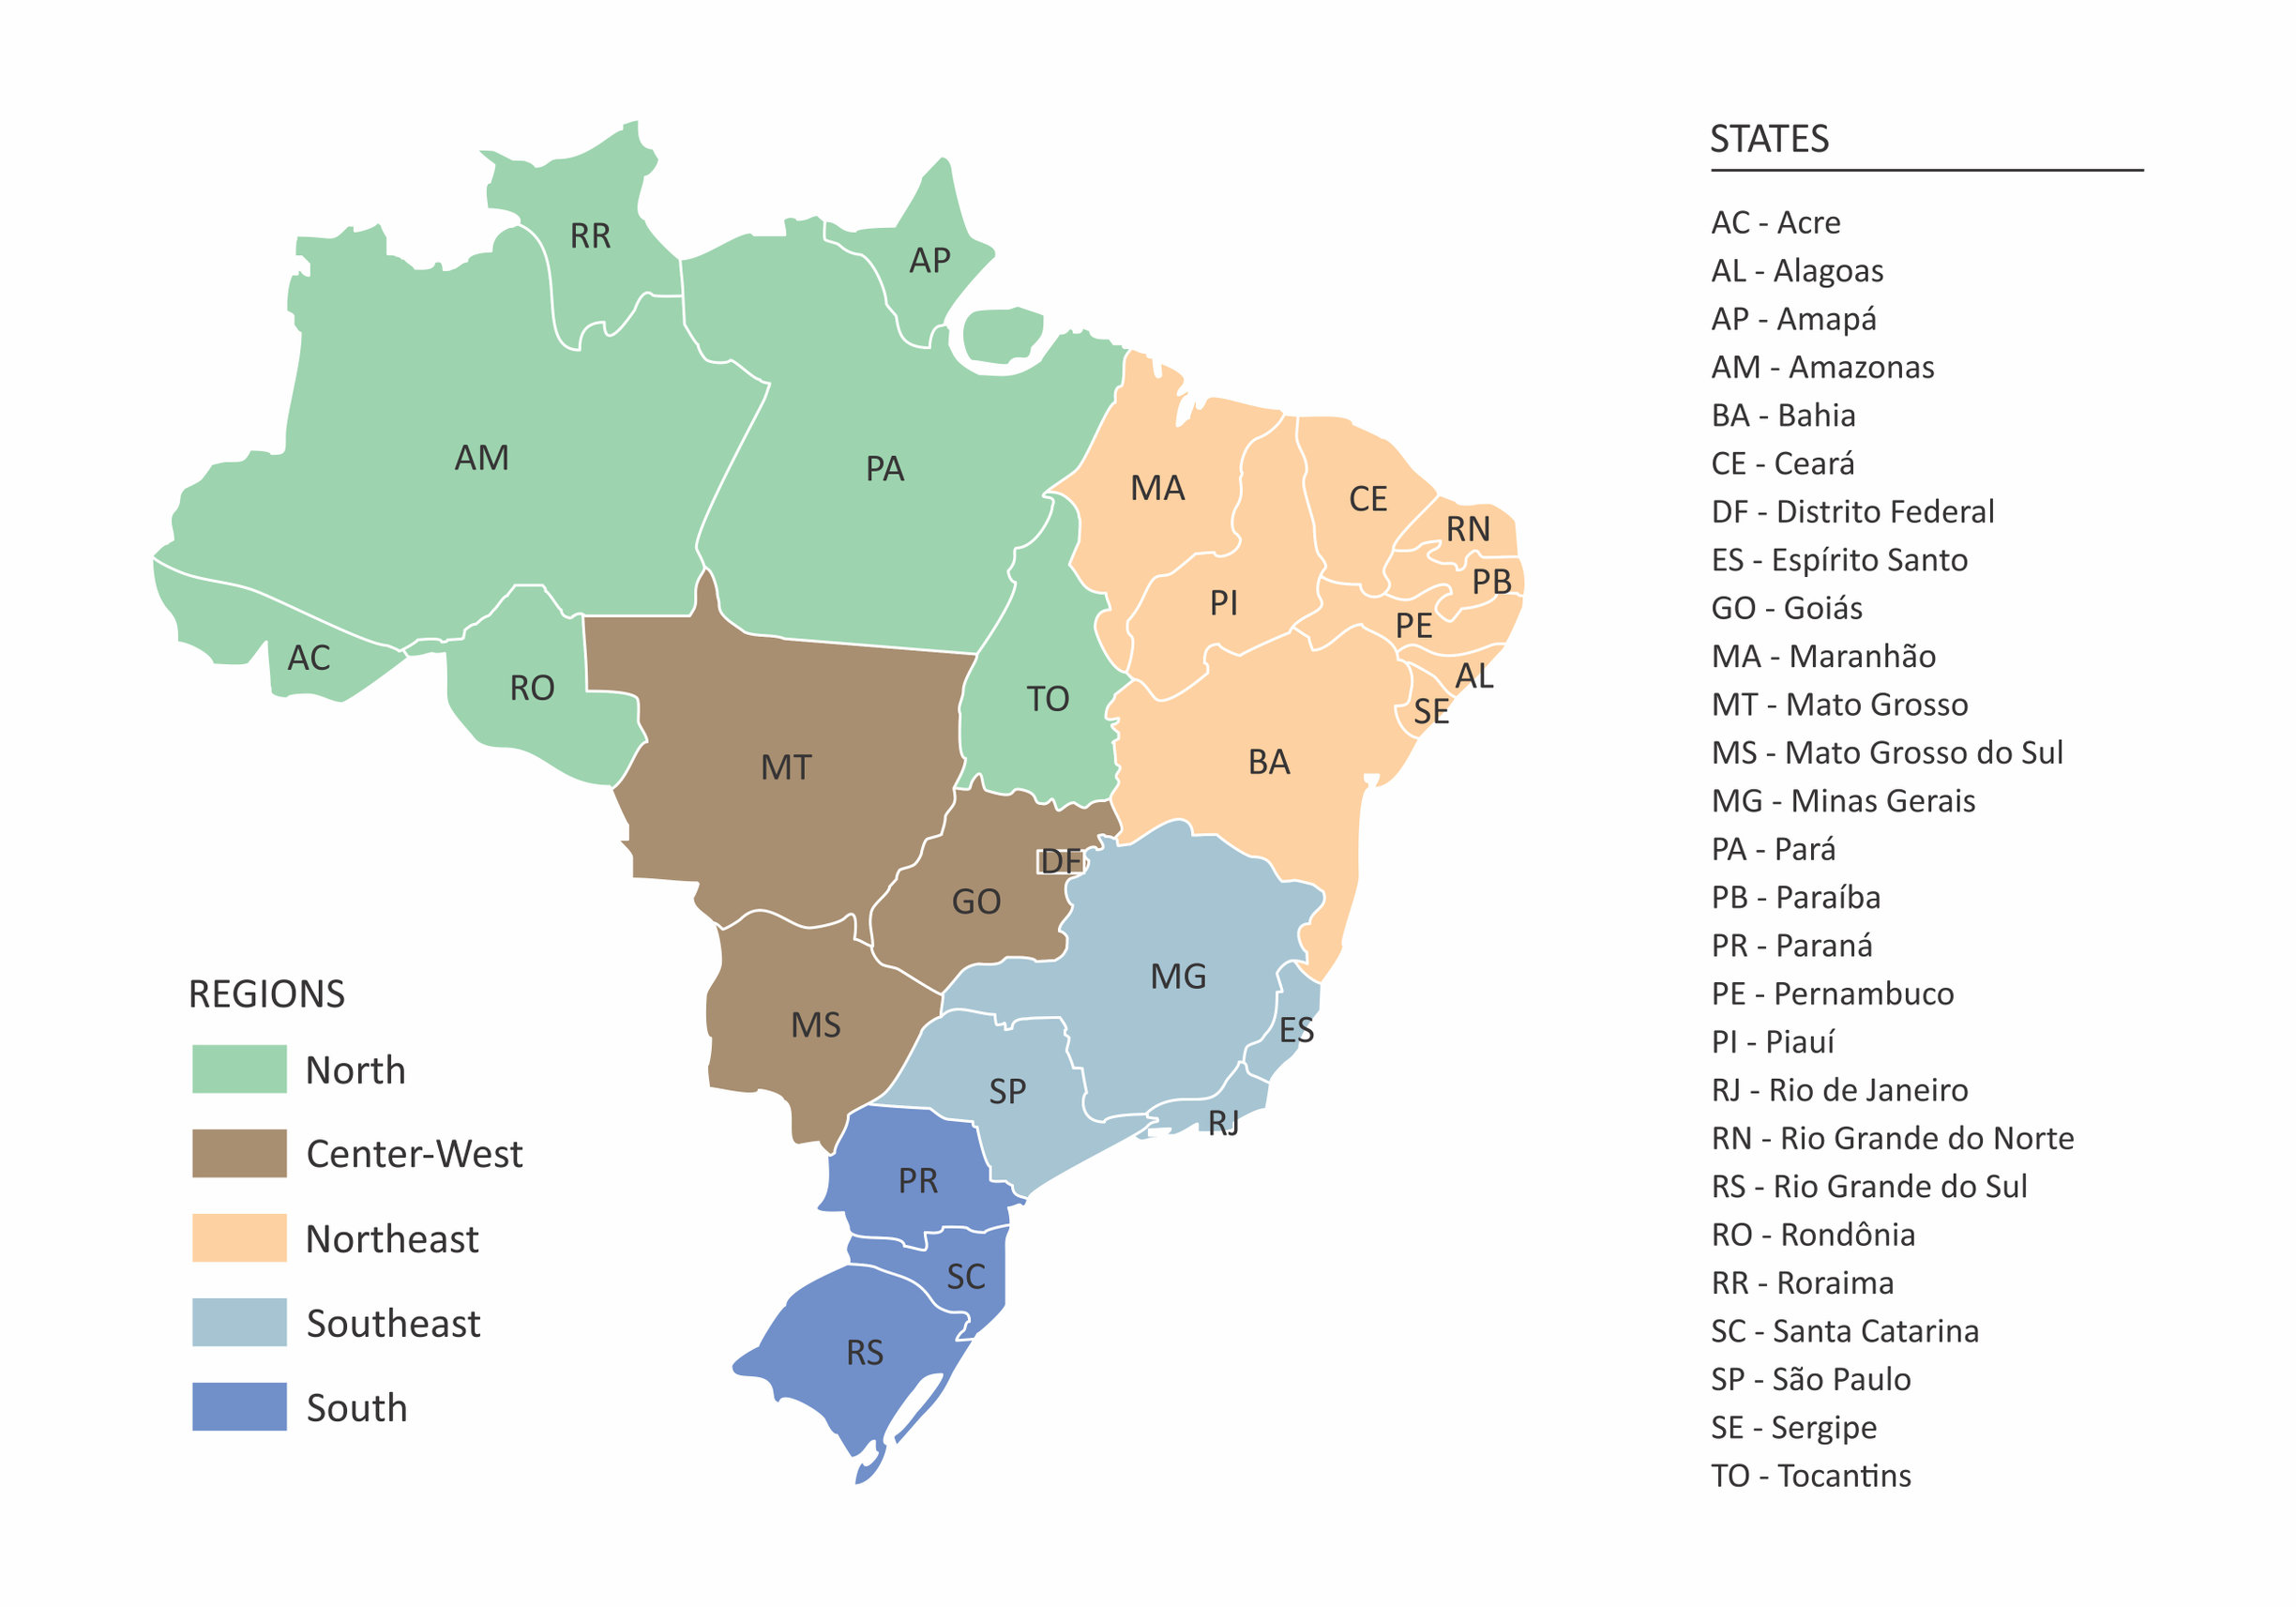

Image taken from https://www.mappr.co/counties/brazil-regions-map/


## 6.1 Geography & Customer Base

To understand Target's market penetration, let us look at the state-wise distribution of customers and the month-over-month order velocity, providing a clear picture of where the brand has established a dominant presence and where growth opportunities remain untapped.

**Month-over-month state-wise order volume:**

In [20]:
query = """

SELECT FORMAT_DATE('%Y-%m', o.order_purchase_timestamp) AS order_month,
       c.customer_state,
       COUNT(o.order_id) AS total_orders
FROM `Target.orders` o
JOIN `Target.customers` c
ON o.customer_id = c.customer_id
GROUP BY 1, 2
ORDER BY 1 ASC, 3 DESC


"""

df = run_query(query)
df

,order_month,customer_state,total_orders
0,2016-09,SP,2
1,2016-09,RS,1
2,2016-09,RR,1
3,2016-10,SP,113
4,2016-10,RJ,56
...,...,...,...
560,2018-09,RJ,3
561,2018-09,SC,1
562,2018-10,SP,2
563,2018-10,RJ,1


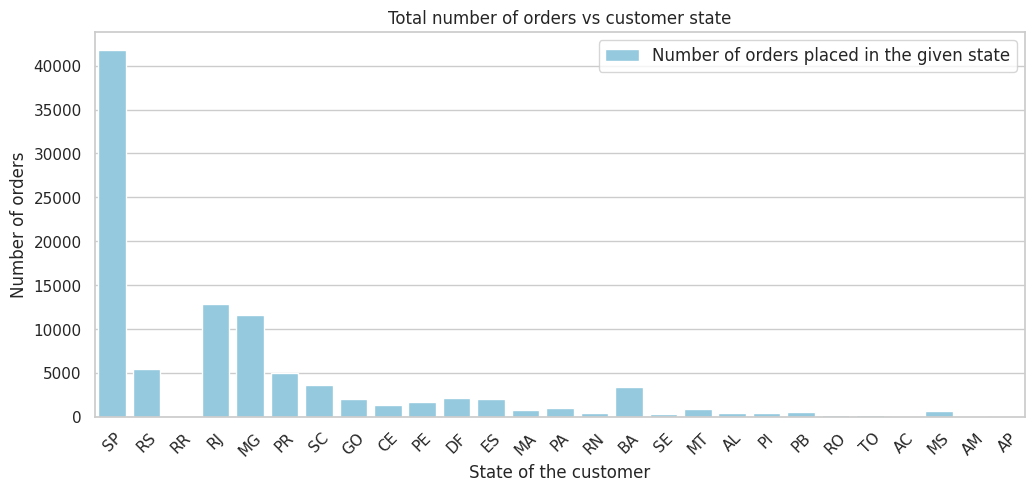

In [21]:
# @title
sns.barplot(data=df, x='customer_state', y='total_orders', color='skyblue', label='Number of orders placed in the given state', estimator=sum, errorbar=None)

plt.title('Total number of orders vs customer state', fontsize=12)
plt.xlabel('State of the customer', fontsize=12)
plt.ylabel('Number of orders', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.savefig('orders_customerstate.png', bbox_inches='tight')
plt.show()
plt.close()

Key Findings:

The majority of the orders come from the state of Sao Paulo (SP) followed by Rio de Janeiro (RJ) and Minas Gerais (MG), all belonging to the South East region.

**State-wise customer distribution:**

In [22]:
query = """

SELECT c.customer_state,
       COUNT(c.customer_id) AS total_customers,
       ROUND(100*COUNT(c.customer_id)/SUM(COUNT(c.customer_id)) OVER(),0) AS customer_percentage
FROM `Target.customers` c
JOIN `Target.orders` o
ON c.customer_id = o.customer_id
GROUP BY 1
ORDER BY 2 DESC

"""

df = run_query(query)

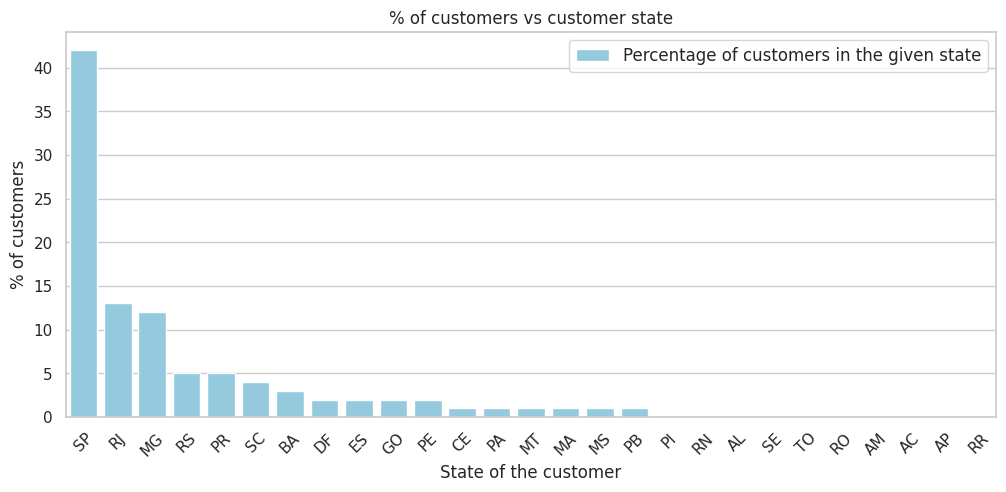

In [23]:
# @title

sns.barplot(data=df, x='customer_state', y='customer_percentage', color='skyblue', label='Percentage of customers in the given state')

plt.title('% of customers vs customer state', fontsize=12)
plt.xlabel('State of the customer', fontsize=12)
plt.ylabel('% of customers', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.savefig('percent_customers_state.png', bbox_inches='tight')
plt.show()
plt.close()

Key Findings:

Similar to the number of orders, most of the customers belong to the state of Sao Paulo (SP) followed by Rio de Janeiro (RJ) and Minas Gerais (MG), all belonging to the South East region amounting to 67% of the total customers in Brazil.

## 6.2 Impact on Order Value

While Target's operations span the entirety of Brazil, the economic contribution of each state varies drastically.

First, let us look at total and average order price. Order price here refers to the total price for a given order. It is computed for every order rather than every item.

In [24]:
query = """

SELECT c.customer_state,
       ROUND(SUM(oi.price),2) AS total_order_price,
       ROUND(SUM(oi.price)/COUNT(DISTINCT oi.order_id),2) AS avg_order_price
FROM `Target.customers` c
INNER JOIN `Target.orders` o
ON c.customer_id = o.customer_id

INNER JOIN `Target.order_items` oi
ON o.order_id = oi.order_id

GROUP BY 1
ORDER BY 3 DESC;

"""

df = run_query(query)

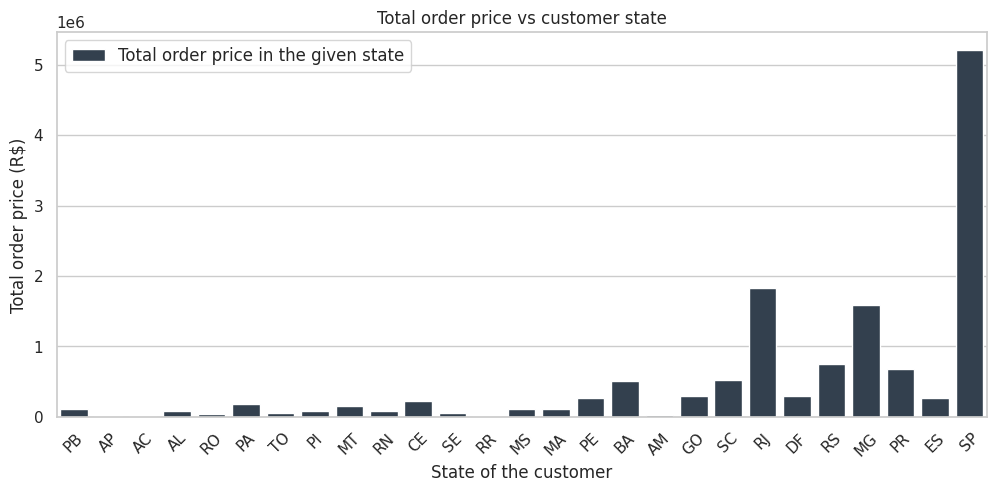

In [25]:
# @title
sns.barplot(data=df, x='customer_state', y='total_order_price', color='#2E4053',
            label='Total order price in the given state')

plt.title('Total order price vs customer state', fontsize=12)
plt.xlabel('State of the customer', fontsize=12)
plt.ylabel('Total order price (R$)', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper left', fontsize=12)
plt.savefig('total_order_price_vs_customer_state.png', bbox_inches='tight')
plt.show()
plt.close()

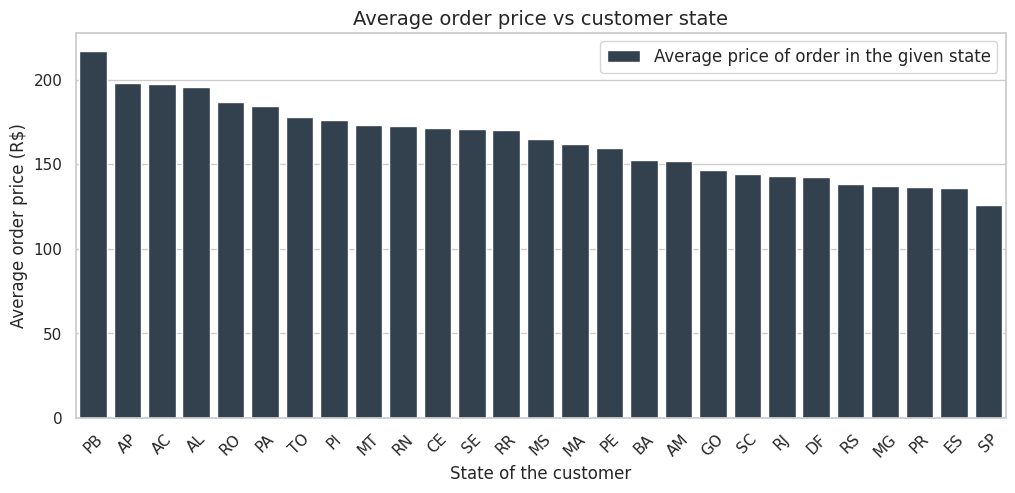

In [26]:
# @title
sns.barplot(data=df, x='customer_state', y='avg_order_price', color='#2E4053', label='Average price of order in the given state')

plt.title('Average order price vs customer state', fontsize=14)
plt.xlabel('State of the customer', fontsize=12)
plt.ylabel('Average order price (R$)', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.savefig('avg_order_price_vs_customer_state.png', bbox_inches='tight')
plt.show()
plt.close()

**Key Findings:**

Urban centers like São Paulo (SP) generates the highest total revenue (R\$ 5M), driven by a massive volume of orders. However, these are high-frequency, low-priced items, resulting in the lowest average order price in the country.

In contrast, remote states like Paraíba (PB) and Amapá (AP) place fewer orders, but those orders carry significantly higher average values.

One can say that customers in remote regions likely "bundle" their purchases or wait to buy high-value items to justify the logistical hurdles discussed in the next section.


## 6.3 Impact on Freight

Freight cost analysis shows that geography is the primary driver of e-commerce friction in Brazil. Similar to order value, let us take a look at the total and average freight costs in the various states.


In [27]:
query = """

SELECT c.customer_state,
       ROUND(SUM(oi.freight_value),2) AS total_order_freight,
       ROUND(SUM(oi.freight_value)/COUNT(DISTINCT oi.order_id),2) AS avg_order_freight
FROM `Target.customers` c
INNER JOIN `Target.orders` o
ON c.customer_id = o.customer_id

INNER JOIN `Target.order_items` oi
ON o.order_id = oi.order_id

GROUP BY 1
ORDER BY 3 DESC;

"""

df = run_query(query)

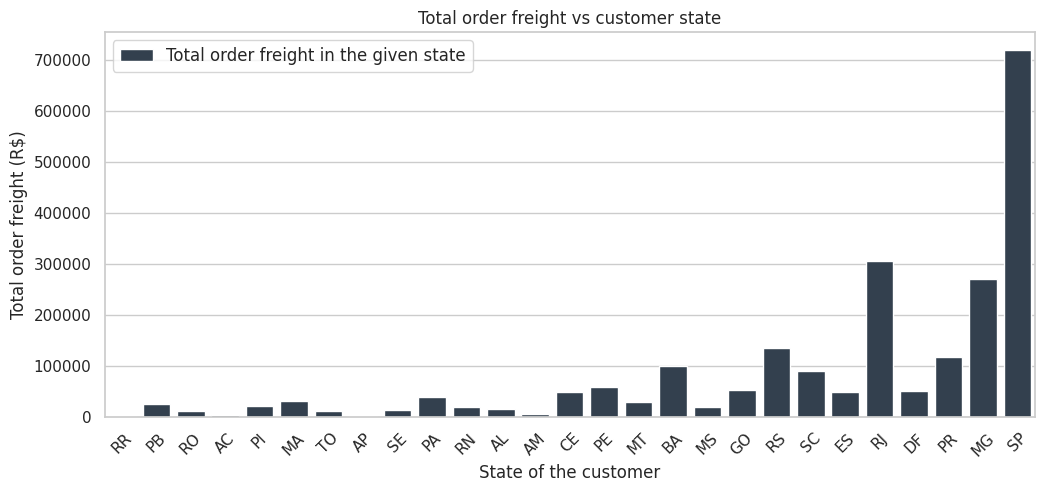

In [28]:
# @title
sns.barplot(data=df, x='customer_state', y='total_order_freight', color='#2E4053', label='Total order freight in the given state')

plt.title('Total order freight vs customer state', fontsize=12)
plt.xlabel('State of the customer', fontsize=12)
plt.ylabel('Total order freight (R$)', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper left', fontsize=12)
plt.savefig('total_order_freight_vs_customer_state.png', bbox_inches='tight')
plt.show()
plt.close()

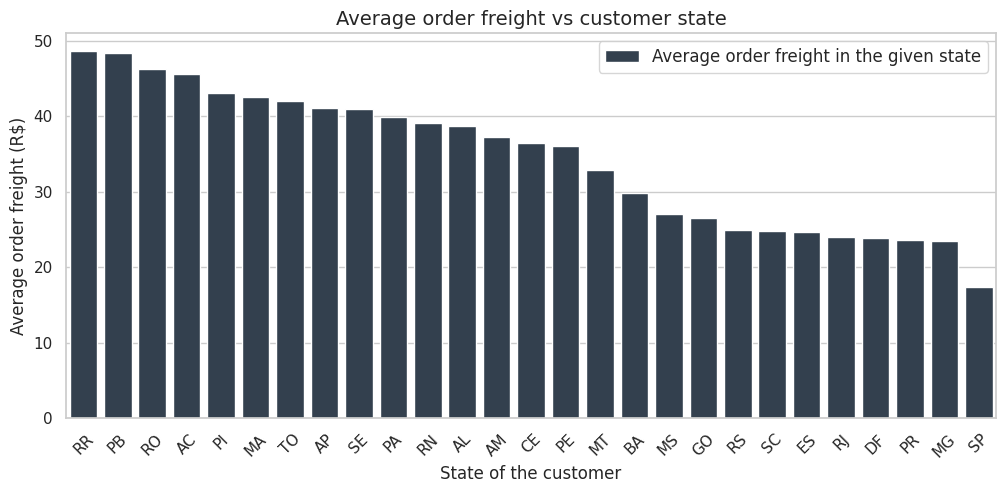

In [29]:
# @title
sns.barplot(data=df, x='customer_state', y='avg_order_freight', color='#2E4053', label='Average order freight in the given state')

# Formatting the plot
plt.title('Average order freight vs customer state', fontsize=14)
plt.xlabel('State of the customer', fontsize=12)
plt.ylabel('Average order freight (R$)', fontsize=12)

# Rotate labels to avoid overlapping if there are many months
plt.xticks(rotation=45)

# Save and close
plt.legend(loc='upper right', fontsize=12)
plt.savefig('avg_order_freight_vs_customer_state.png', bbox_inches='tight')
plt.show()
plt.close()

**Key Findings:**

Urban centers like SP, RJ, MG etc have clear infrastructure advantage and benefit from established transportation networks, keeping average freight costs at a minimum.

In contrast, remote states such as RR in the North region face average freight costs nearly 2.8 times higher than those in SP. The complexity of transporting goods across the Amazon rainforest region adds substantial logistical costs on the customers.


## 6.4 Imbalance in Marketplace Activity

To explore additional factors affecting the shipping costs, we can study the geographic distribution of the sellers and the customers.


In [30]:
query = """

WITH seller_location AS (
SELECT CASE WHEN seller_state IN ('AC', 'AM', 'RO', 'RR', 'PA', 'AP', 'TO') THEN 'North'
            WHEN seller_state IN ('MT', 'MS', 'GO', 'DF') THEN 'Center West'
            WHEN seller_state IN ('ES', 'MG', 'RJ', 'SP') THEN 'South East'
            WHEN seller_state IN ('PR', 'SC', 'RS') THEN 'South'
            WHEN seller_state IN ('BA', 'SE', 'AL', 'PE', 'PB', 'RN', 'CE', 'PI', 'MA') THEN 'North East'
            ELSE 'Undefined'
       END AS region,
       ROUND(100*COUNT(seller_id)/SUM(COUNT(seller_id)) OVER(),2) AS seller_percentage
FROM `Target.sellers`
GROUP BY 1
),

customer_location AS(
SELECT CASE WHEN customer_state IN ('AC', 'AM', 'RO', 'RR', 'PA', 'AP', 'TO') THEN 'North'
            WHEN customer_state IN ('MT', 'MS', 'GO', 'DF') THEN 'Center West'
            WHEN customer_state IN ('ES', 'MG', 'RJ', 'SP') THEN 'South East'
            WHEN customer_state IN ('PR', 'SC', 'RS') THEN 'South'
            WHEN customer_state IN ('BA', 'SE', 'AL', 'PE', 'PB', 'RN', 'CE', 'PI', 'MA') THEN 'North East'
            ELSE 'Undefined'
       END AS region,
       ROUND(100*COUNT(customer_id)/SUM(COUNT(customer_id)) OVER(),2) AS customer_percentage
FROM `Target.customers`
GROUP BY 1
)

SELECT s.region, s.seller_percentage, c.customer_percentage
FROM seller_location s
INNER JOIN customer_location c
ON s.region = c.region
ORDER BY 2 DESC;



"""

df = run_query(query)
df

,region,seller_percentage,customer_percentage
0,South East,73.89,68.65
1,South,21.58,14.23
2,Center West,2.55,5.81
3,North East,1.81,9.45
4,North,0.16,1.86


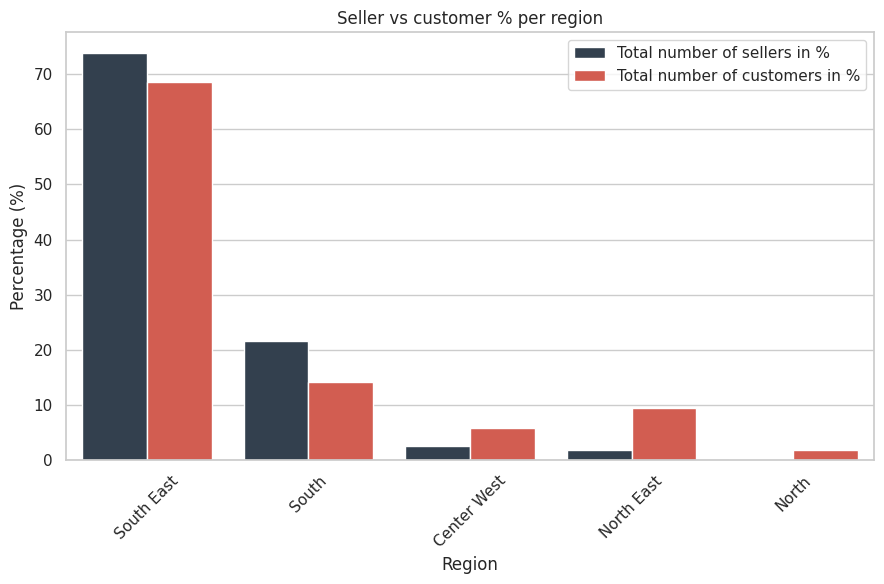

In [31]:
df_melted = df.melt(id_vars='region', value_vars=['seller_percentage', 'customer_percentage'])

plt.figure(figsize=(9, 6))
sns.barplot(data=df_melted, x='region', y='value', hue='variable', palette=['#2E4053', '#E74C3C'])

plt.title('Seller vs customer % per region', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Total number of sellers in %', 'Total number of customers in %'], title=None)


plt.tight_layout()
plt.savefig('customer_seller_percent.png')

**Key Findings:**

A staggering 95% of sellers are concentrated in the South and South East regions.

Because the North region accounts for less than 0.20% of sellers, almost every order to a customer in the North must travel long distances across challenging terrain, significantly increasing the shipping costs.

## 6.5 Impact on Delivery Times
Considering the logistical and geographic challenges outlined aboves,  it is reasonable to expect longer delivery times in more remote regions. A thorough analysis presented below confirms this pattern and reveals some interesting insights.

First, let us first look at five states with the fastest and slowest average delivery times.



**States with the fastest and slowest average delivery times:**

In [32]:
query = """

(SELECT c.customer_state,
        ROUND(AVG(DATE_DIFF(o.order_delivered_customer_date,o.order_purchase_timestamp, DAY)),2) AS avg_delivery_time,
       'Fastest' AS delivery_time_category
FROM `Target.customers` c
INNER JOIN `Target.orders` o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY 1
ORDER BY 2
LIMIT 5)

UNION ALL

(SELECT c.customer_state,
        ROUND(AVG(DATE_DIFF(o.order_delivered_customer_date,o.order_purchase_timestamp, DAY)),2) AS avg_delivery_time,
       'Slowest' AS delivery_time_category
FROM `Target.customers` c
INNER JOIN `Target.orders` o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY 1
ORDER BY 2 DESC
LIMIT 5)
ORDER BY delivery_time_category, avg_delivery_time;

"""

run_query(query)

,customer_state,avg_delivery_time,delivery_time_category
0,SP,8.30,Fastest
1,PR,11.53,Fastest
2,MG,11.54,Fastest
3,DF,12.51,Fastest
4,SC,14.48,Fastest
5,PA,23.32,Slowest
6,AL,24.04,Slowest
7,AM,25.99,Slowest
8,AP,26.73,Slowest
9,RR,28.98,Slowest


The pattern is largely as expected. SP and neighboring states exhibit the fastest delivery times, while more remote states experience the slowest.
To further refine the analysis, let us find the states where actual delivery times significantly outperform the estimated delivery times.

**States where actual delivery times outperform the estimated delivery time:**

In [33]:
query = """

SELECT c.customer_state,
       ROUND(AVG(DATE_DIFF(o.order_estimated_delivery_date,o.order_delivered_customer_date, DAY)),2) AS early_delivery_avg_days
FROM `Target.customers` c
INNER JOIN `Target.orders` o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
AND o.order_delivered_customer_date < o.order_estimated_delivery_date
GROUP BY 1
ORDER BY 2 DESC
LIMIT 5;

"""

run_query(query)

,customer_state,early_delivery_avg_days
0,RR,23.75
1,AP,21.87
2,AC,21.26
3,AM,20.28
4,RO,19.86


The results reveal an interesting pattern. While remote states were previously identified as having the longest delivery times, the above results show that orders to these regions often arrive well before their estimated delivery dates—even when the total delivery time remains high. This suggests that delivery estimates for these areas may be intentionally conservative.

To examine this more closely, let us compare the average actual delivery time with the estimated delivery time across each state.

**State-wise actual delivery time vs estimated delivery time:**

In [34]:
query = """

SELECT c.customer_state,
       ROUND(AVG(DATE_DIFF(o.order_delivered_customer_date, o.order_purchase_timestamp, DAY)),1) AS avg_delivery_days,
       ROUND(AVG(DATE_DIFF(o.order_estimated_delivery_date, o.order_purchase_timestamp, DAY)),1) AS avg_estimated_delivery_days,
       ROUND(AVG(DATE_DIFF(o.order_estimated_delivery_date, o.order_purchase_timestamp, DAY)) - AVG(DATE_DIFF(o.order_delivered_customer_date, o.order_purchase_timestamp, DAY)),1) AS difference
FROM `Target.customers` c
JOIN `Target.orders` o
ON c.customer_id = o.customer_id
WHERE order_status = 'delivered' AND order_delivered_customer_date IS NOT NULL
GROUP BY 1
ORDER BY 4;

"""

run_query(query)

,customer_state,avg_delivery_days,avg_estimated_delivery_days,difference
0,AL,24.0,32.2,8.2
1,MA,21.1,30.1,9.0
2,SE,21.0,30.5,9.5
3,ES,15.3,25.2,9.9
4,BA,18.9,29.1,10.2
5,CE,20.8,31.0,10.2
6,MS,15.2,25.6,10.4
7,SP,8.3,18.8,10.5
8,PI,19.0,29.7,10.7
9,SC,14.5,25.4,10.9


**Key Findings:**

One of the most interesting findings in the dataset is how Target manages customer expectations.

**Conservative Estimates:** The data indicates that Target consistently sets conservative (later) estimated delivery dates across all states, with particularly cautious estimates for more remote regions.

**The Paradox:** Even though remote states have the slowest absolute delivery times, they have the highest "early delivery" rates relative to their estimates.

**But why provide conservative estimates?**

The answer lies in the correlation between delivery timing and review scores.

## 6.6 Psychology behind Managing Customer Expectations

Let us group customer review score into four categories:

*   Good fwhenor review score >= 4
*   Neutral when review score = 3
*   Bad when review score = 2
*   Very Bad when review score = 1

**Impact of late deliveries on review scores:**

In [35]:
query = """
WITH late_delivery_review AS (
       SELECT CASE WHEN r.review_score >= 4 THEN 'Good'
                   WHEN r.review_score = 3 THEN 'Neutral'
                   WHEN r.review_score = 2 THEN 'Bad'
                   ELSE 'Very Bad'
              END AS review_category
       FROM `Target.orders` o
       INNER JOIN `Target.order_reviews` r
       ON o.order_id = r.order_id
       WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
       AND o.order_delivered_customer_date > o.order_estimated_delivery_date
)

SELECT review_category,
       COUNT(*) AS total_count,
       ROUND(100*COUNT(*)/SUM(COUNT(*)) OVER(),2) AS percentage
FROM late_delivery_review
GROUP BY 1
ORDER BY 3 DESC;

"""

run_query(query)

,review_category,total_count,percentage
0,Very Bad,3554,46.16
1,Good,2665,34.61
2,Neutral,875,11.36
3,Bad,606,7.87


Almost 54% of the reviews are poor with 46% resulting in Very Bad reviews when delivery dates are delayed than estimation.

**Impact of early deliveries on review scores:**

In [36]:
query = """
WITH early_delivery_review AS (
       SELECT CASE WHEN r.review_score >= 4 THEN 'Good'
                   WHEN r.review_score = 3 THEN 'Neutral'
                   WHEN r.review_score = 2 THEN 'Bad'
                   ELSE 'Very Bad'
              END AS review_category
       FROM `Target.orders` o
       INNER JOIN `Target.order_reviews` r
       ON o.order_id = r.order_id
       WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
       AND o.order_delivered_customer_date <= o.order_estimated_delivery_date
)

SELECT review_category,
       COUNT(*) AS total_count,
       ROUND(100*COUNT(*)/SUM(COUNT(*)) OVER(),2) AS percentage
FROM early_delivery_review
GROUP BY 1
ORDER BY 3 DESC;

"""

run_query(query)

,review_category,total_count,percentage
0,Good,73381,82.77
1,Neutral,7086,7.99
2,Very Bad,5851,6.60
3,Bad,2335,2.63


When the deliveries are early, more than 80% of the reviews are Good. Bad and Very Bad reviews total to only ~9%.

**Key Findings:**

When an order is delivered later than the estimate, 54% of reviews are poor, with nearly half resulting in a "Very Bad" rating.

However, When an order arrives on or before the estimate, customer satisfaction skyrockets, with over 80% of reviews being "Good."

# 7. Installment Culture and Financial Drivers

## 7.1 Credit Dominance

To understand the financial landscape of Target's operations, let us analyze the preference for various payment types.

In [37]:
query = """

SELECT
    FORMAT_DATE('%Y-%m', o.order_purchase_timestamp) AS order_month,
    COUNT(DISTINCT CASE WHEN p.payment_type = 'credit_card' THEN o.order_id END) AS credit_card_orders,
    COUNT(DISTINCT CASE WHEN p.payment_type = 'voucher' THEN o.order_id END) AS voucher_orders,
    COUNT(DISTINCT CASE WHEN p.payment_type = 'UPI' THEN o.order_id END) AS upi_orders,
    COUNT(DISTINCT CASE WHEN p.payment_type = 'debit_card' THEN o.order_id END) AS debit_card_orders,
    COUNT(DISTINCT CASE WHEN p.payment_type = 'not_defined' THEN o.order_id END) AS undefined_orders
FROM `Target.orders` o
INNER JOIN `Target.payments` p
ON o.order_id = p.order_id
GROUP BY 1
ORDER BY 1;

"""

df = run_query(query)

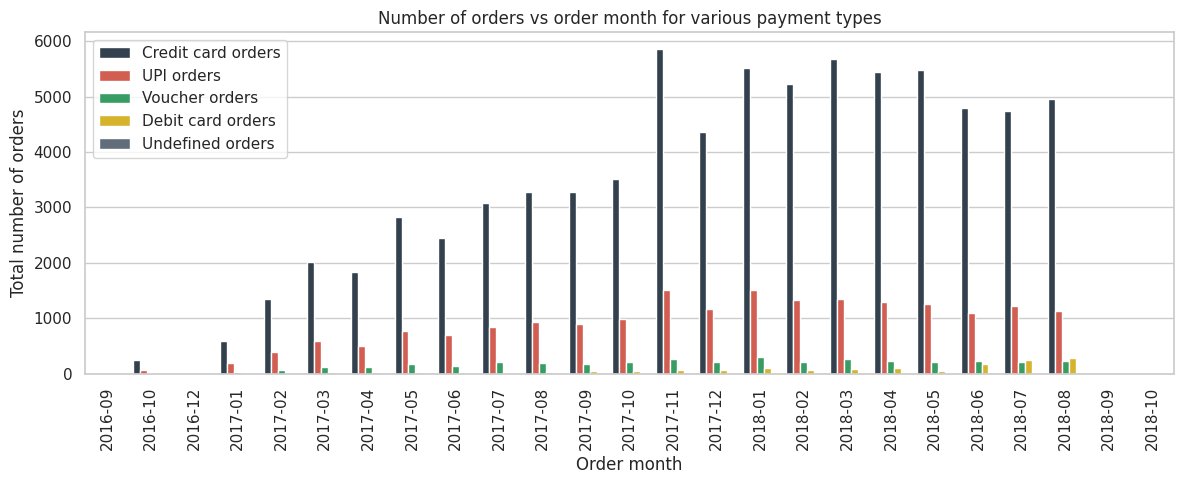

In [38]:
# @title
df_melted = df.melt(id_vars='order_month', value_vars=['credit_card_orders', 'upi_orders', 'voucher_orders', 'debit_card_orders', 'undefined_orders'])

sns.barplot(data=df_melted, x='order_month', y='value', hue='variable', palette=['#2E4053', '#E74C3C', '#27AE60', '#F1C40F', '#5D6D7E'])

plt.title('Number of orders vs order month for various payment types', fontsize=12)
plt.xlabel('Order month', fontsize=12)
plt.ylabel('Total number of orders', fontsize=12)
plt.xticks(rotation=90)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Credit card orders', 'UPI orders', 'Voucher orders', 'Debit card orders', 'Undefined orders'], title=None)

plt.tight_layout()
plt.savefig('payment_types.png')

In [39]:
query = """

SELECT payment_type,
       ROUND(100*COUNT(order_id)/SUM(COUNT(order_id)) OVER(), 2) AS percentage
FROM `Target.payments`
GROUP BY 1
ORDER BY 2 DESC;

"""

run_query(query)

,payment_type,percentage
0,credit_card,73.92
1,UPI,19.04
2,voucher,5.56
3,debit_card,1.47
4,not_defined,0.00


The data reveals a clear market leader, credit cards, which facilitate approximately 74% of all the transactions.

From January 2017 to August 2018, credit card usage experienced a staggering 752% increase, growing from 582 to 4,963 monthly orders.

UPI or Brazilian Boleto stands as the second most popular choice, mirroring the growth trend of credit cards but at a smaller scale. Traditional methods like vouchers and debit cards represent a marginal share, though debit card usage has seen an increase since mid-2018.

The seasonal peak in November (Black Friday) is heavily credit-dependent. Between October and November 2017, total orders jumped by 67%, a surge almost entirely fulfilled via credit cards and UPI. This highlights that Brazilian consumers rely on credit availability to participate in major retail events.

## 7.2 Installment Culture

A unique characteristic of the Brazilian market is the widespread use of payments in installments. While nearly 49% of orders are paid in full, the remaining majority utilizes multi-month payment plans.

In [40]:
query = """

SELECT p.payment_installments,
       COUNT(DISTINCT o.order_id) AS total_paid_orders,
       ROUND(100*(COUNT(DISTINCT o.order_id))/SUM(COUNT(DISTINCT o.order_id)) OVER(),2) AS percentage
FROM `Target.payments` p
INNER JOIN `Target.orders` o
ON p.order_id = o.order_id
WHERE o.order_status NOT IN ('canceled', 'unavailable','created')
GROUP BY 1
ORDER BY 1
LIMIT 24
OFFSET 1

"""

df = run_query(query)
df

,payment_installments,total_paid_orders,percentage
0,1,48394,48.85
1,2,12265,12.38
2,3,10324,10.42
3,4,7006,7.07
4,5,5172,5.22
5,6,3876,3.91
6,7,1607,1.62
7,8,4214,4.25
8,9,630,0.64
9,10,5232,5.28


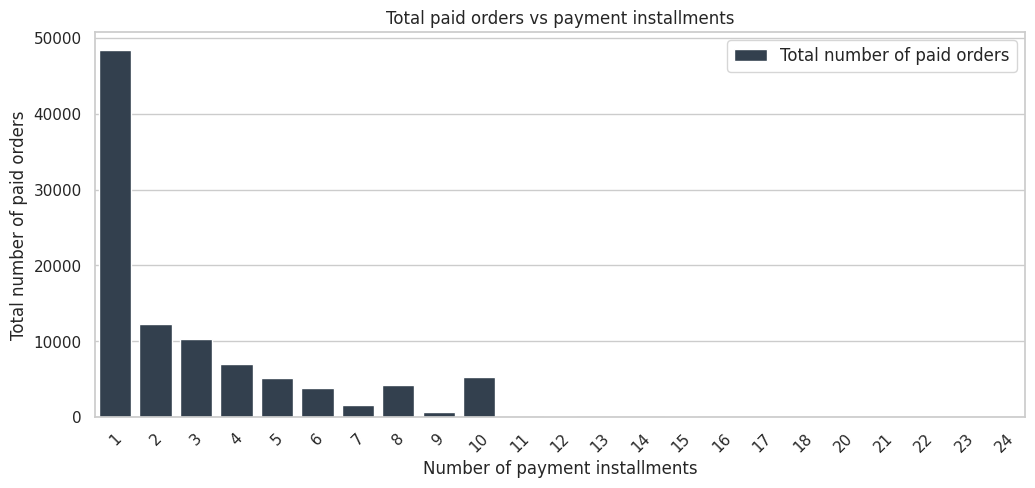

In [41]:
sns.barplot(data=df, x='payment_installments', y='total_paid_orders', color='#2E4053', label='Total number of paid orders')

plt.title('Total paid orders vs payment installments', fontsize=12)
plt.xlabel('Number of payment installments', fontsize=12)
plt.ylabel('Total number of paid orders', fontsize=12)

plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.savefig('total_orders_vs_installments.png', bbox_inches='tight')
plt.show()
plt.close()

**The 10-Month Threshold:**
There is a clear preference for installment plans of up to 10 months, after which order volumes drop sharply. One possible explanation is that customers may face additional interest costs beyond this point.


To evaluate this, one can compare the total order cost (item price + shipping) with what the customer actually paid.

Total order cost = Price of all the items in the order + shipping charges
Ratio = Total payment value / Total order cost

If the ratio is 1.0, it simply means that the customer paid the exact amount for the order with no additional costs.

If the ratio is less than 1.0, it could be an indication of potential discounts and if the ratio is greater than 1.0, it can indicate additional costs.

In [42]:
query = """

WITH calc_order_value AS (
       SELECT order_id,
              SUM(price) AS total_item_price,
              SUM(freight_value) AS total_shipping
       FROM `Target.order_items`
       GROUP BY 1
),

calc_order_payment AS (
       SELECT order_id,
              payment_installments,
              SUM(payment_value) AS total_payment
       FROM `Target.payments`
       GROUP BY 1,2
)

SELECT op.payment_installments,
       ROUND(AVG(ov.total_item_price+ov.total_shipping),2) AS avg_order_cost,
       ROUND(AVG(op.total_payment),2) AS avg_payment_value,
       ROUND(AVG(op.total_payment)/AVG(ov.total_item_price+ov.total_shipping),2) AS ratio
FROM calc_order_value ov
INNER JOIN calc_order_payment op
ON ov.order_id = op.order_id
GROUP BY 1
ORDER BY 1;

"""

run_query(query)

,payment_installments,avg_order_cost,avg_payment_value,ratio
0,0,94.31,94.31,1.00
1,1,122.38,119.91,0.98
2,2,129.32,127.39,0.99
3,3,144.45,142.82,0.99
4,4,165.84,164.13,0.99
5,5,185.96,183.79,0.99
6,6,212.36,209.86,0.99
7,7,189.01,187.63,0.99
8,8,309.98,308.76,1.00
9,9,199.59,198.97,1.00


**Key Findings:**

The average order cost and average payment value are comparable with ratio less than 1.0 for upto 10 installments. The ratio does not deviate significantly from 1.0 for >10 installments and do not justify decline in orders purely due to interest rates.

A more plausible factor is the composition of the product catalog. Like many online retailers, Target might not have many high-value items that would typically require longer installment plans.


In [43]:
query = """

SELECT CASE WHEN price < 50 THEN 'Category 1: < R$50'
            WHEN price >= 50 AND price < 100 THEN 'Category 2: R$50 - R$100'
            WHEN price >= 100 AND price < 500 THEN 'Category 3: R$100 - R$500'
            WHEN price >= 500 AND price < 2000 THEN 'Category 4: R$500 - R$2000'
            ELSE 'Category 5: R$ > 2000'
       END AS price_category,
       COUNT(DISTINCT product_id) AS distinct_products,
       ROUND(100 * COUNT(DISTINCT product_id) / SUM(COUNT(DISTINCT product_id)) OVER(), 1) AS percentage
FROM `Target.order_items`
GROUP BY 1
ORDER BY 1 ;

"""

run_query(query)

,price_category,distinct_products,percentage
0,Category 1: < R$50,11450,33.9
1,Category 2: R$50 - R$100,9031,26.7
2,Category 3: R$100 - R$500,11753,34.8
3,Category 4: R$500 - R$2000,1452,4.3
4,Category 5: R$ > 2000,90,0.3


**Key Findings:**

Most of the products in the inventory fall within R\$100-R\$500 and high-end products with R\$>2000 are relatively scarce.

However, it is interesting to note that the average order cost jumps from R\$236 to R\$615 at 24 installments showing a staggering 161\% rise, highlighting potentially expensive items bought with long-term credit availability. Similar spikes are observed at 15 and 20 installments.

This suggests that these long term installments are not being used to buy the same set of products slowly but rather to unlock a higher price range of products. However, the limited availability of such high-end items may therefore be constraining overall sales in this segment.

# 8. Actionable Insights & Recommendations

### Flash sales in the afternoon:
To better monetize the existing peak traffic in the afternoons, Target can introduce short-term flash sales, for example from 16:00 - 18:00 when people leave work.

### Targeted advertising before seasonal events:
As order volumes in Brazil are event-driven (such as Black Friday, Christmas, Father's Day, Mother's Day), the marketing team can introduce dedicated advertisements on offers and deals before the event begin to attract customer attention and interest.

### Expanding to the northern region:
95% of sellers and 83% of customers are located in South East and South regions. Outside this main hub, BA has a strong customer base. Establishing a Target warehouse in BA can be helpful to reach outside the main hub. This can also drastically reduce the delivery time and freight costs not only in the North East region but also in the Center West and North regions.

### Realistic estimated date of delivery:
The current data show that the estimated delivery date is overly conservative in all the states by at least 8 days on average. While early deliveries lead to more positive reviews, it can likely cause significant dropouts during checkouts. Modifying the algorithm to provide a tighter but still realistic estimated date of delivery can improve the number of orders without compromising customer reviews. Providing a sooner estimated delivery date encourages customers to complete their orders and still have positive reviews through early delivery.

### Onboarding for local sellers:
Target can provide incentives or onboarding program to local sellers in North and Center West regions and encourage them to list their products on Target. For example, reduced commission rates for the first 6 months. This strategy can expand the seller concentration beyond the main hub and also potentially reduce delivery times and freight costs in the remote regions.

### Limit based free shipping in remote areas:
Additionally, to tackle the problem of high freight cost in remote areas, Target can offer free shipping up to a certain limit. This cost can be balanced by asking sellers in South and South East region to reduce the shipping fee as Target provides them with huge order volumes.

### Expand inventory with high-end products:
As credit card is the popular choice of payment in Brazil, Target's revenue is dependent on credit availability. The current data shows that there is an interest for high-end products but the number of such products available on the inventory are limited. Target can increase the number of high-end products in the inventory to make use of the interest free long term instalments.
